In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
dataset_path = "brain_tumor_dataset"


In [5]:
train_path ="C:/Users/Ganesh/Downloads/archive (4)/Training"
test_path = "C:/Users/Ganesh/Downloads/archive (4)/Testing"


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)


In [8]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 2236 images belonging to 4 classes.
Found 558 images belonging to 4 classes.


In [9]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1600 images belonging to 4 classes.


In [10]:
print("Classes:", train_data.class_indices)


Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [12]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:



from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)



In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3512 - loss: 2.2215
Epoch 1: val_accuracy improved from None to 0.65591, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.4490 - loss: 1.9566 - val_accuracy: 0.6559 - val_loss: 1.4101 - learning_rate: 1.0000e-04
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6149 - loss: 1.5389
Epoch 2: val_accuracy improved from 0.65591 to 0.75806, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.6212 - loss: 1.5104 - val_accuracy: 0.7581 - val_loss: 1.1993 - learning_rate: 1.0000e-04
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6761 - loss: 1.3655
Epoch 3: val_accuracy improved from 0.75806 to 0.80824, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6950 - loss: 1.3285 - val_accuracy: 0.8082 - val_loss: 1.0777 - learning_rate: 1.0000e-04
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6905 - loss: 1.3037
Epoch 4: val_accuracy did not improve from 0.80824
70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7245 - loss: 1.2359 - val_accuracy: 0.8011 - val_loss: 1.0238 - learning_rate: 1.0000e-04
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7352 - loss: 1.1559
Epoch 5: val_accuracy improved from 0.80824 to 0.84229, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7509 - loss: 1.1386 - val_accuracy: 0.8423 - val_loss: 0.9729 - learning_rate: 1.0000e-04
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7438 - loss: 1.1218
Epoch 6: val_accuracy did not improve from 0.84229
70/70 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7625 - loss: 1.1059 - val_accuracy: 0.8405 - val_loss: 0.9503 - learning_rate: 1.0000e-04
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7903 - loss: 1.0571
Epoch 7: val_accuracy did not improve from 0.84229
70/70 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.7831 - loss: 1.0651 - val_accuracy: 0.8208 - val_loss: 0.9324 - learning_rate: 1.0000e-04
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7890 - loss: 1.0124
Epoch 8: val_accuracy improved from 0.84229 to 0.84946, saving model to best_model.h5


...


Epoch 12: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8399 - loss: 0.9074 - val_accuracy: 0.8763 - val_loss: 0.8063 - learning_rate: 1.0000e-04
Epoch 13/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8361 - loss: 0.9094
Epoch 13: val_accuracy did not improve from 0.87634
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8345 - loss: 0.9042 - val_accuracy: 0.8620 - val_loss: 0.8137 - learning_rate: 1.0000e-04
Epoch 14/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8422 - loss: 0.8843
Epoch 14: val_accuracy improved from 0.87634 to 0.88351, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8386 - loss: 0.8862 - val_accuracy: 0.8835 - val_loss: 0.7765 - learning_rate: 1.0000e-04
Epoch 15/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8514 - loss: 0.8440
Epoch 15: val_accuracy did not improve from 0.88351
70/70 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8453 - loss: 0.8510 - val_accuracy: 0.8602 - val_loss: 0.7984 - learning_rate: 1.0000e-04
Epoch 16/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8606 - loss: 0.8219
Epoch 16: val_accuracy improved from 0.88351 to 0.89247, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8479 - loss: 0.8538 - val_accuracy: 0.8925 - val_loss: 0.7576 - learning_rate: 1.0000e-04
Epoch 17/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8590 - loss: 0.8140
Epoch 17: val_accuracy did not improve from 0.89247
70/70 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8506 - loss: 0.8322 - val_accuracy: 0.8781 - val_loss: 0.7454 - learning_rate: 1.0000e-04
Epoch 18/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8727 - loss: 0.8088
Epoch 18: val_accuracy did not improve from 0.89247
70/70 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8681 - loss: 0.8011 - val_accuracy: 0.8889 - val_loss: 0.7495 - learning_rate: 1.0000e-04
Epoch 19/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8644 - loss: 0.7840
Epoch 19: val_accuracy did not improve from 0.89247
70/70 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8672 - loss: 0.7929 - val_accuracy: 0.8763 - val_loss: 0


Epoch 21: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8685 - loss: 0.7694 - val_accuracy: 0.8996 - val_loss: 0.7012 - learning_rate: 1.0000e-04
Epoch 22/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8707 - loss: 0.7517
Epoch 22: val_accuracy improved from 0.89964 to 0.90502, saving model to best_model.h5



Epoch 22: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8734 - loss: 0.7539 - val_accuracy: 0.9050 - val_loss: 0.6873 - learning_rate: 1.0000e-04
Epoch 23/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8874 - loss: 0.7315
Epoch 23: val_accuracy did not improve from 0.90502
70/70 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8801 - loss: 0.7428 - val_accuracy: 0.9014 - val_loss: 0.6926 - learning_rate: 1.0000e-04
Epoch 24/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8715 - loss: 0.7573
Epoch 24: val_accuracy did not improve from 0.90502
70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8739 - loss: 0.7466 - val_accuracy: 0.8943 - val_loss: 0.6885 - learning_rate: 1.0000e-04
Epoch 25/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8692 - loss: 0.7234
Epoch 25: val_accuracy did not improve from 0.90502
70/70 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8757 - loss: 0.7224 - val_accuracy: 0.8961 - val_loss: 0

In [17]:
predictions = model.predict(test_data)
pred_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())


50/50 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step


In [18]:
print("\nClassification Report:\n")

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
))



Classification Report:

              precision    recall  f1-score   support

      glioma       0.86      0.73      0.79       400
  meningioma       0.78      0.66      0.71       400
     notumor       0.92      0.97      0.94       400
   pituitary       0.79      0.99      0.88       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.83      1600
weighted avg       0.84      0.84      0.83      1600



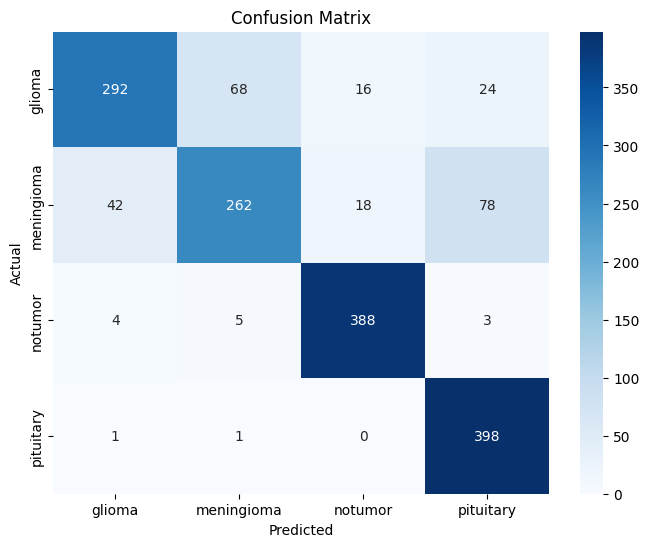

In [19]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


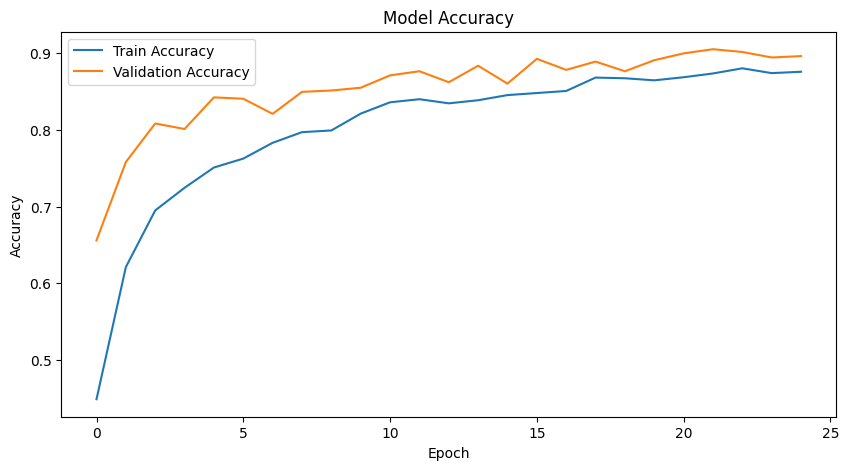

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()


In [21]:
model.save("brain_tumor_model.h5")

print("\nModel Saved Successfully!")



Model Saved Successfully!


In [22]:
from tensorflow.keras.preprocessing import image

img_path =  "C:/Users/Ganesh/Downloads/archive (4)/Testing/glioma/Te-gl_95.jpg"
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

print("\nPredicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Predicted Class: glioma


In [23]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [24]:
import gradio as gr
import tensorflow as tf
from PIL import Image
import numpy as np

model = tf.keras.models.load_model("brain_tumor_model.h5")

def predict(image):
    image = image.resize((224, 224))
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)[0][0]

    if prediction > 0.5:
        return "Tumor Detected"
    else:
        return "No Tumor"

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text"
)

demo.launch()

C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [25]:
from tensorflow.keras.models import load_model
import os
print(os.path.exists(r"C:/Users/Ganesh/brain_MRI/brain_tumor_MRI.keras"))


False


In [26]:
import os
for root,dirs,files in os.walk(r"C:/Users/Ganesh"):
    for file in files:
        if file.endswith(".keras") or file.endswith(".h5"):
            print(os.path.join(root,file))

C:/Users/Ganesh\best_model.h5
C:/Users/Ganesh\best_model.keras
C:/Users/Ganesh\brain_tumor_model.h5
C:/Users/Ganesh\brain_tumor_mri_project.keras
C:/Users/Ganesh\generator_model.h5
C:/Users/Ganesh\.keras\models\mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5
C:/Users/Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\h5py\tests\data_files\vlen_string_dset.h5
C:/Users/Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\h5py\tests\data_files\vlen_string_dset_utc.h5
C:/Users/Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\h5py\tests\data_files\vlen_string_s390x.h5


In [27]:
from tensorflow.keras.models import load_model
model=load_model(r"C:/Users/Ganesh/best_model.keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,198,408 (27.46 MB)

 Trainable params: 2,388,098 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 4,776,198 (18.22 MB)